In [2]:
import numpy as np
import pandas as pd 

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Business Problem Understanding
- to predict based on the input columns if a person joins this organization what likekly can be his salary

In [4]:
df= pd.read_csv("job_salary_prediction_dataset.csv")
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [5]:
df1 = df.copy()

# Data Understanding and EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [7]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [8]:
df['job_title'].unique()

array(['AI Engineer', 'Data Analyst', 'Frontend Developer',
       'Business Analyst', 'Product Manager', 'Backend Developer',
       'Machine Learning Engineer', 'DevOps Engineer',
       'Software Engineer', 'Cybersecurity Analyst', 'Data Scientist',
       'Cloud Engineer'], dtype=object)

In [9]:
df['job_title'].value_counts()

job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

In [10]:
df['experience_years'].value_counts()

experience_years
14    12166
18    12102
15    12052
1     12011
4     12001
7     11981
20    11958
2     11950
12    11944
16    11908
3     11890
19    11875
5     11862
6     11860
9     11856
8     11822
0     11804
10    11777
11    11747
17    11735
13    11699
Name: count, dtype: int64

In [11]:
df['education_level'].value_counts()

education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

In [12]:
df['skills_count'].value_counts()

skills_count
14    13298
9     13267
8     13266
1     13250
3     13248
17    13214
16    13213
5     13196
6     13184
10    13181
18    13152
19    13136
13    13101
2     13092
15    13064
7     13052
4     13040
11    13037
12    13009
Name: count, dtype: int64

In [13]:
df['industry'].value_counts()

industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841
Name: count, dtype: int64

In [14]:
df['company_size'].value_counts()

company_size
Large         50254
Small         50235
Medium        50027
Enterprise    49875
Startup       49609
Name: count, dtype: int64

In [15]:
df['location'].value_counts()

location
Australia      25258
Canada         25165
Sweden         25100
Remote         25065
Singapore      25035
USA            24931
UK             24927
India          24895
Netherlands    24861
Germany        24763
Name: count, dtype: int64

In [16]:
df['remote_work'].value_counts()

remote_work
No        83621
Hybrid    83476
Yes       82903
Name: count, dtype: int64

In [17]:
df['certifications'].value_counts()

certifications
0    42015
3    41974
2    41744
1    41574
4    41467
5    41226
Name: count, dtype: int64

In [18]:
df['salary'].describe()

count    250000.000000
mean     145718.080524
std       37407.952729
min       31867.000000
25%      119358.000000
50%      143453.000000
75%      169492.000000
max      333046.000000
Name: salary, dtype: float64

In [19]:
df['salary'].skew()

0.3794009747285935

In [20]:
df.isna().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [21]:
continuous = ['salary']
discrete_count= ['skills_count','certifications']
descrete_categorical= ['job_title','experience_years','education_level','industry','company_size','location','remote_work']

## For Discrete variables

In [22]:
df[descrete_categorical].describe()

,experience_years
count,250000.000000
mean,10.005408
std,6.060602
min,0.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,20.000000


In [23]:
df[discrete_count].describe()

,skills_count,certifications
count,250000.000000,250000.000000
mean,9.997812,2.491928
std,5.479288,1.706475
min,1.000000,0.000000
25%,5.000000,1.000000
50%,10.000000,2.000000
75%,15.000000,4.000000
max,19.000000,5.000000


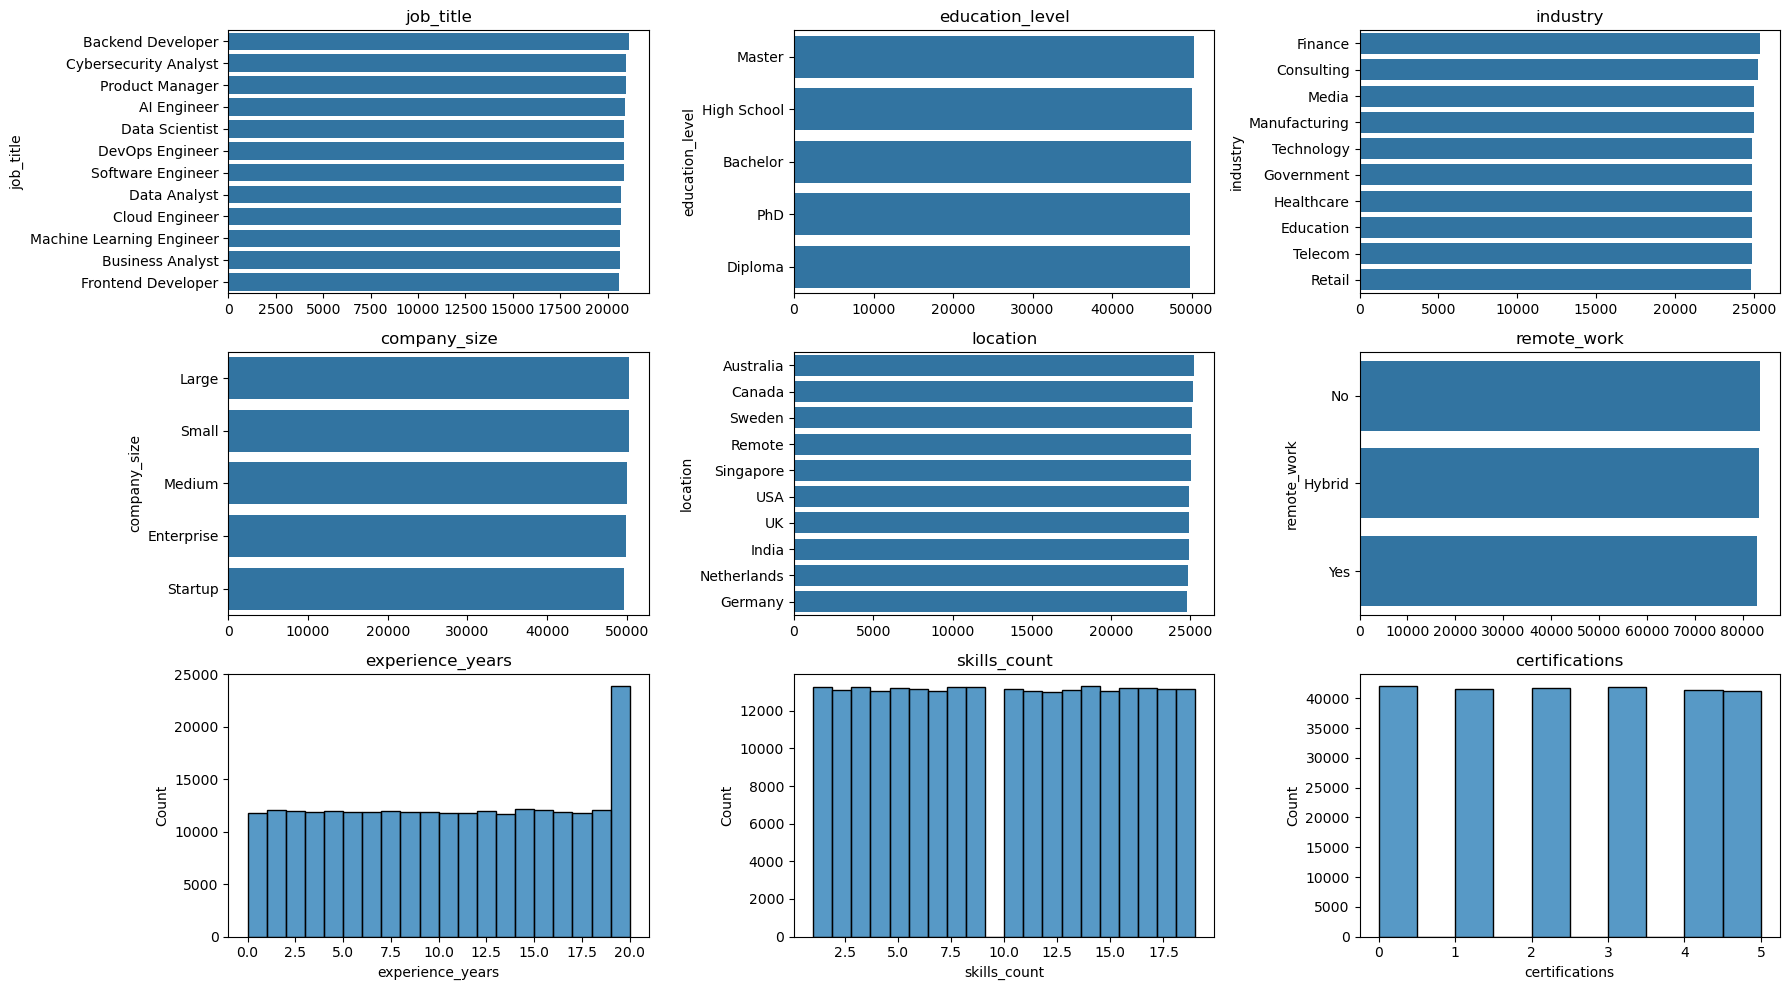

In [24]:
plt.figure(figsize=(18,10))

cat_cols = ['job_title','education_level','industry',
            'company_size','location','remote_work']

for i, col in enumerate(cat_cols, 1):
    plt.subplot(3,3,i)
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index)
    plt.title(col)

# numeric-discrete columns
plt.subplot(3,3,7)
sns.histplot(df['experience_years'], bins=20)
plt.title('experience_years')

plt.subplot(3,3,8)
sns.histplot(df['skills_count'], bins=20)
plt.title('skills_count')

plt.subplot(3,3,9)
sns.histplot(df['certifications'], bins=10)
plt.title('certifications')

plt.tight_layout()
plt.show()

In [25]:
df.groupby('job_title')['salary'].agg(['mean','median','min','max','count'])

,mean,median,min,max,count
job_title,,,,,
AI Engineer,173498.480640,171674.0,66371,333046,20945
Backend Developer,139202.768663,136678.0,46304,290512,21125
Business Analyst,122551.231354,120562.0,39285,264567,20648
Cloud Engineer,152102.535290,150005.0,45030,292855,20686
Cybersecurity Analyst,148697.695548,146737.0,54224,303178,20959
Data Analyst,119891.696603,118079.5,31867,249354,20722
Data Scientist,147258.214409,145231.5,51349,288049,20890
DevOps Engineer,149959.266791,148021.0,54985,304968,20889
Frontend Developer,132653.842485,130619.0,44964,277053,20633


Text(0.5, 1.0, 'Job Title vs Salary')

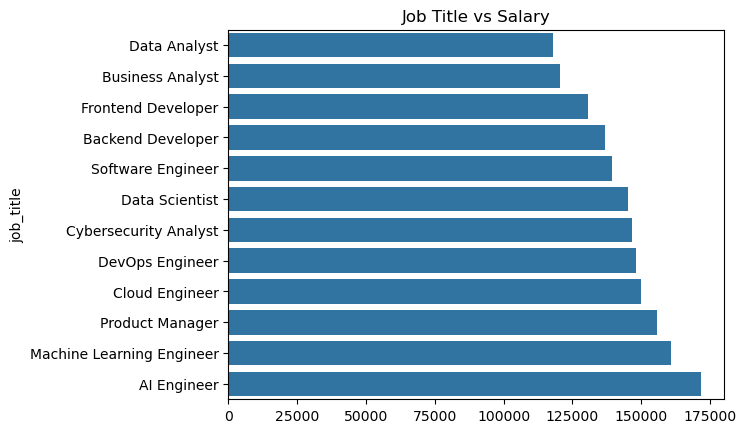

In [26]:
job_salary = df.groupby('job_title')['salary'].median().sort_values()
sns.barplot(x=job_salary.values, y=job_salary.index)
plt.title("Job Title vs Salary")

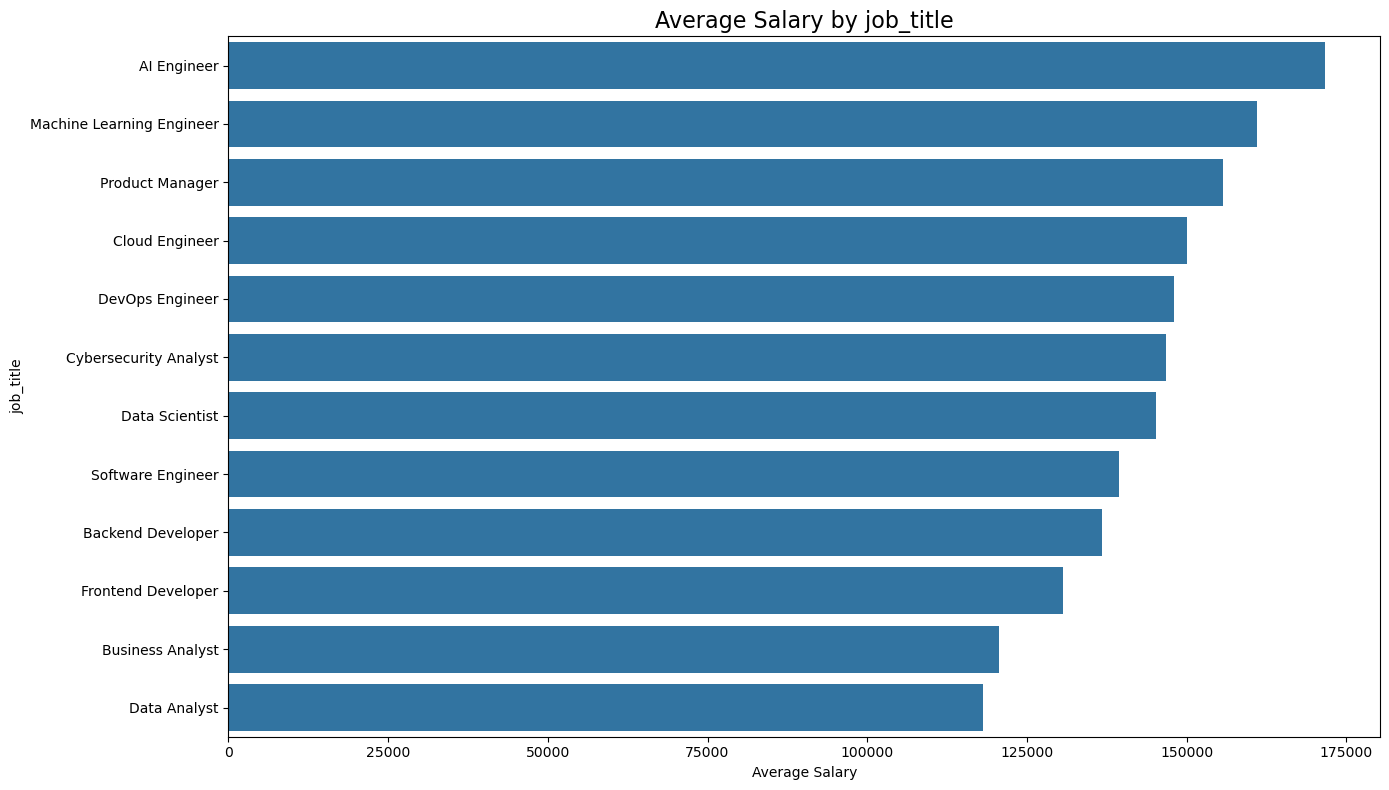

In [27]:
job_salary = df.groupby('job_title')['salary'].median().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=job_salary.values,
    y=job_salary.index
)

plt.title("Average Salary by job_title", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("job_title")

plt.tight_layout()
plt.show()

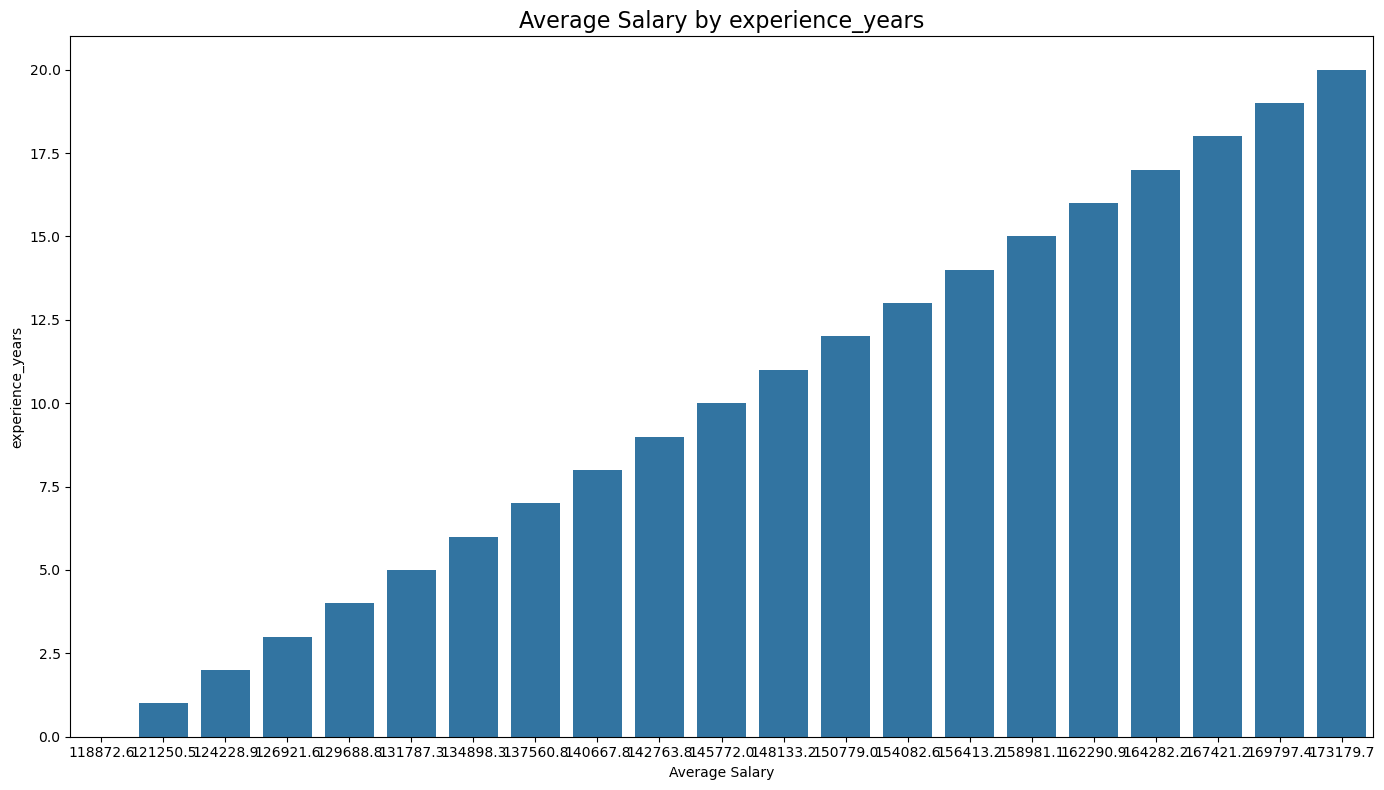

In [28]:
skills_counts = df.groupby('experience_years')['salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=skills_counts.values.round(1),
    y=skills_counts.index
)

plt.title("Average Salary by experience_years", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("experience_years")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'education_level vs Salary')

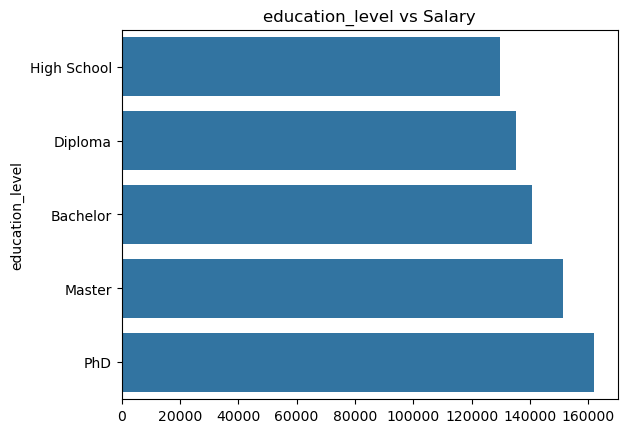

In [29]:
job_salary = df.groupby('education_level')['salary'].median().sort_values()
sns.barplot(x=job_salary.values, y=job_salary.index)
plt.title("education_level vs Salary")

In [30]:
pd.crosstab(df['job_title'], df['education_level'])

education_level,Bachelor,Diploma,High School,Master,PhD
job_title,,,,,
AI Engineer,4212,4178,4211,4192,4152
Backend Developer,4179,4200,4346,4333,4067
Business Analyst,4079,4065,4135,4230,4139
Cloud Engineer,4198,4120,4248,4068,4052
Cybersecurity Analyst,4182,4203,4141,4279,4154
Data Analyst,4206,4126,4088,4161,4141
Data Scientist,4145,4246,4135,4186,4178
DevOps Engineer,4038,4168,4201,4248,4234
Frontend Developer,4103,4112,4113,4106,4199


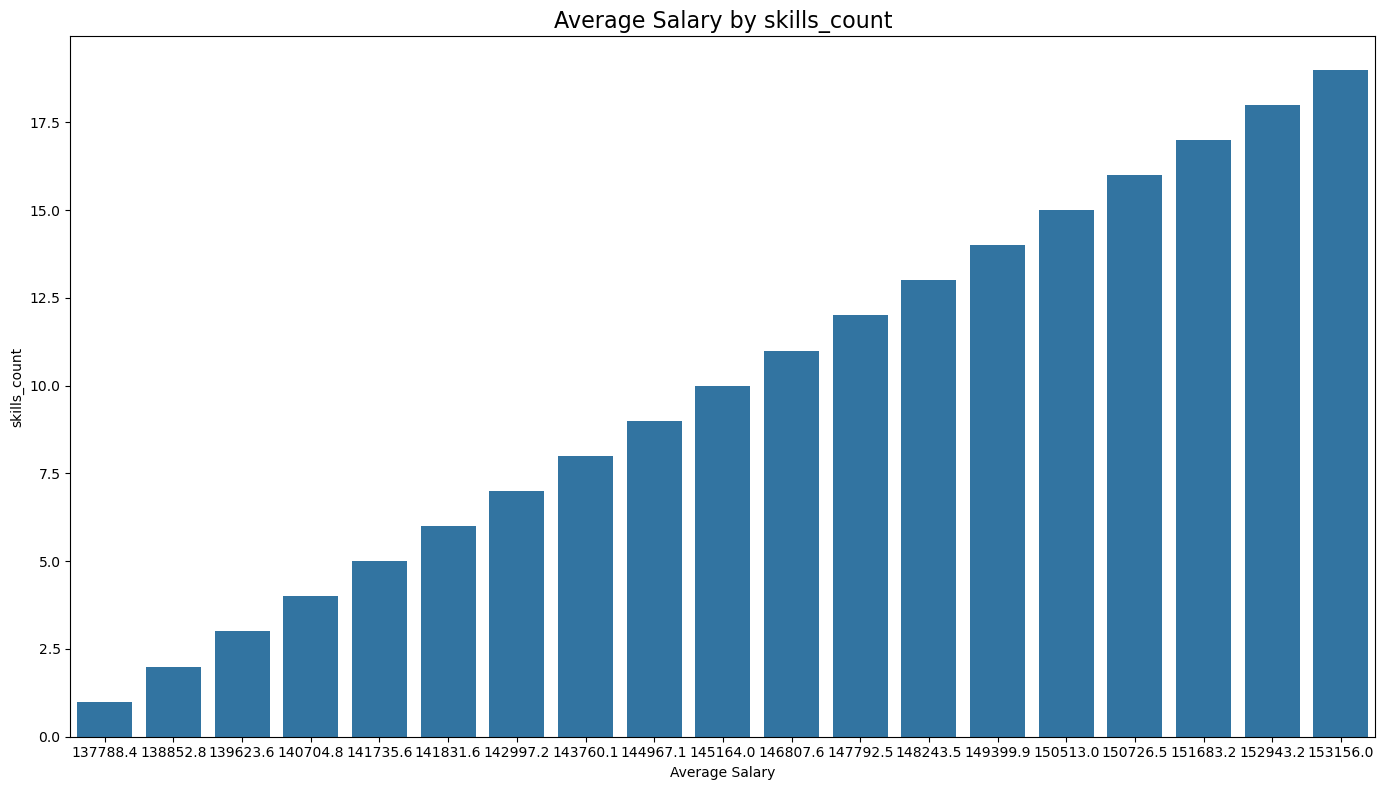

In [31]:
skills_counts = df.groupby('skills_count')['salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=skills_counts.values.round(1),
    y=skills_counts.index
)

plt.title("Average Salary by skills_count", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("skills_count")

plt.tight_layout()
plt.show()

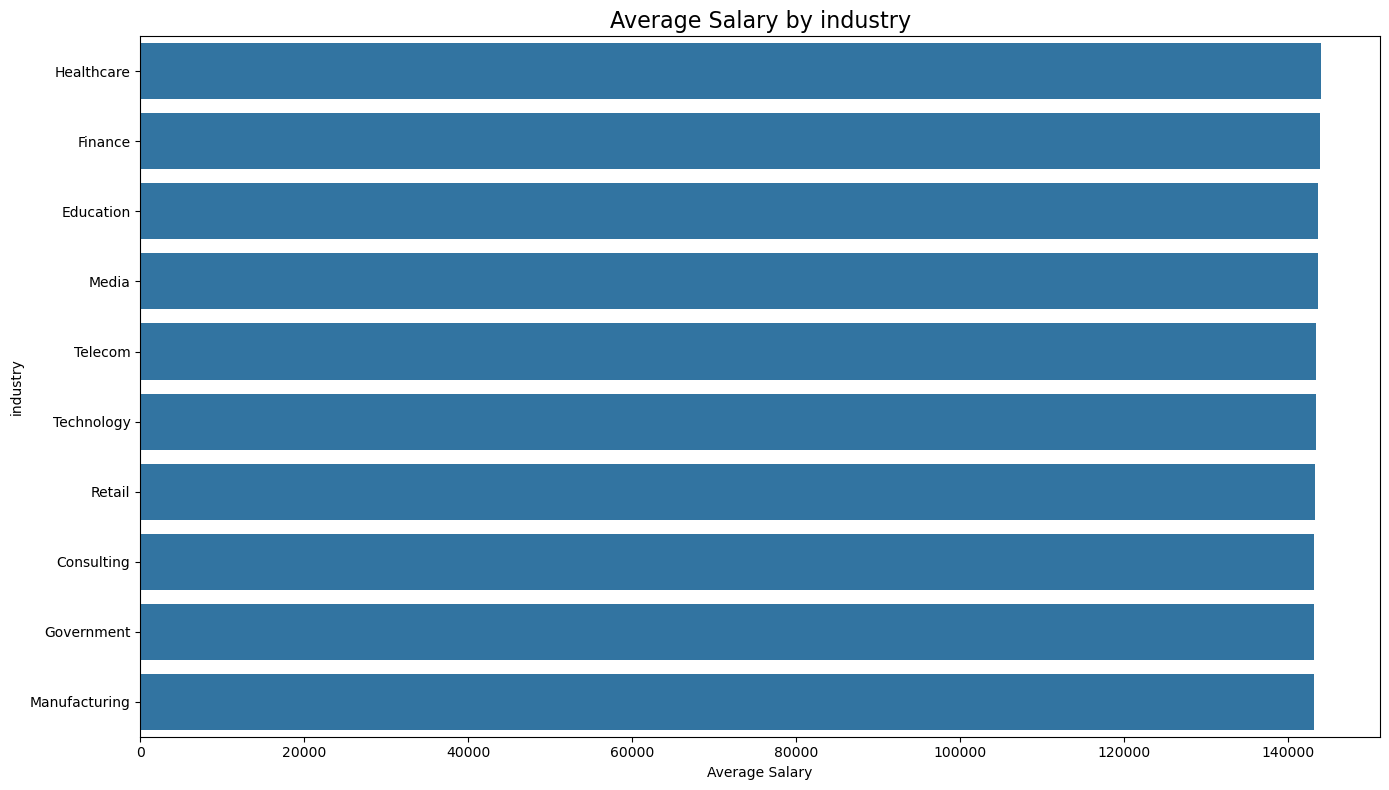

In [32]:
skills_counts = df.groupby('industry')['salary'].median().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=skills_counts.values,
    y=skills_counts.index
)

plt.title("Average Salary by industry", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("industry")

plt.tight_layout()
plt.show()

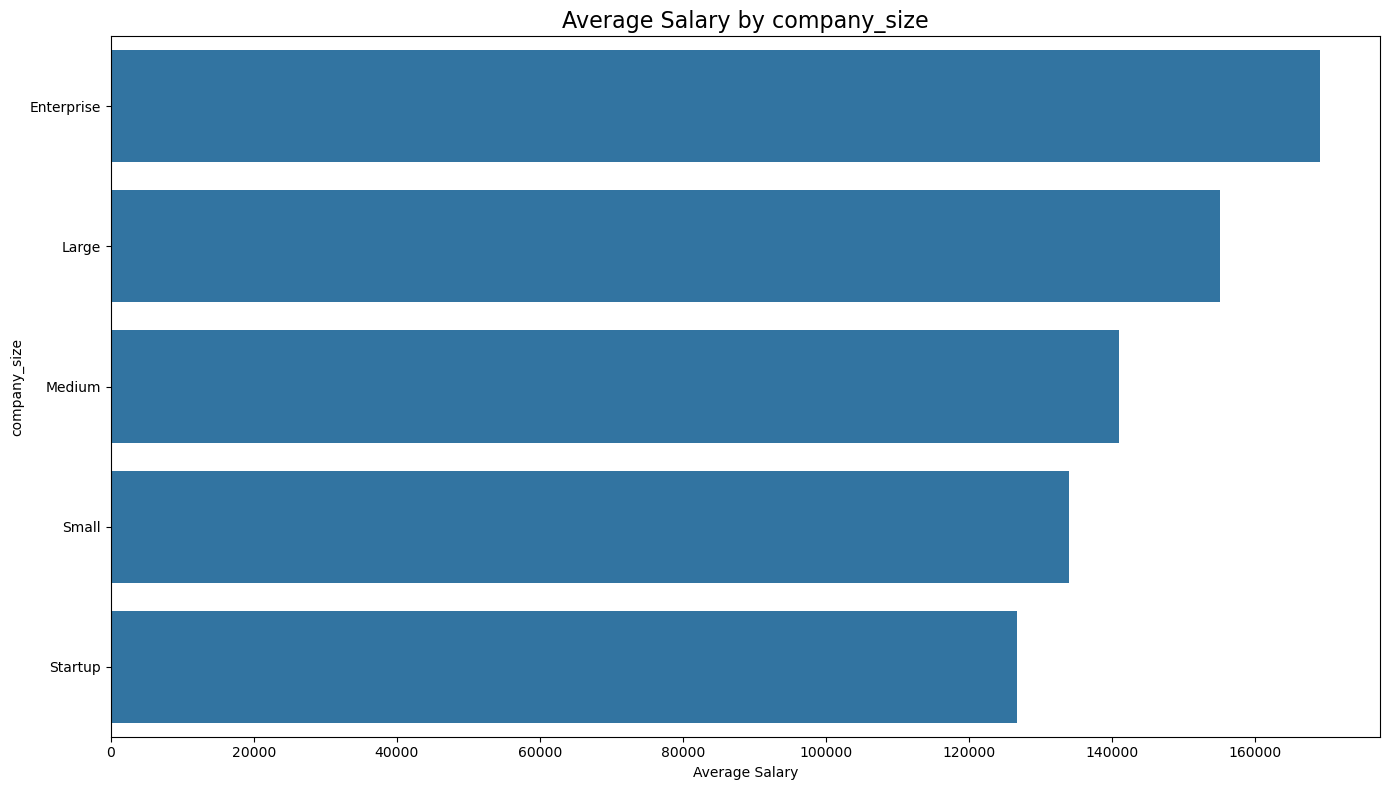

In [33]:
skills_counts = df.groupby('company_size')['salary'].median().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=skills_counts.values.round(1),
    y=skills_counts.index
)

plt.title("Average Salary by company_size", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("company_size")

plt.tight_layout()
plt.show()

In [34]:
pd.crosstab(df['experience_years'], df['company_size'])

company_size,Enterprise,Large,Medium,Small,Startup
experience_years,,,,,
0,2428,2362,2343,2329,2342
1,2388,2390,2392,2462,2379
2,2331,2443,2422,2373,2381
3,2303,2356,2445,2394,2392
4,2413,2479,2349,2437,2323
5,2404,2372,2402,2345,2339
6,2385,2313,2355,2369,2438
7,2366,2404,2424,2400,2387
8,2419,2410,2295,2352,2346


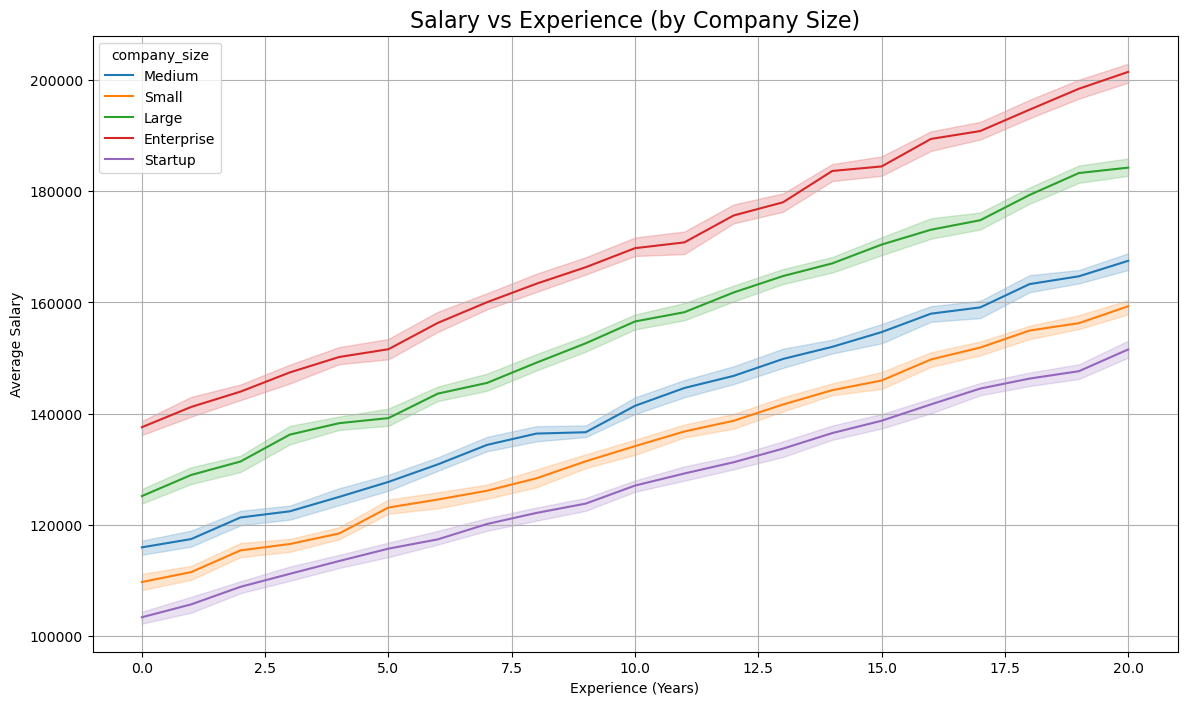

In [35]:
plt.figure(figsize=(14,8))

sns.lineplot(
    data=df,
    x='experience_years',
    y='salary',
    hue='company_size',
    estimator='median'   # important: averages salary
)

plt.title("Salary vs Experience (by Company Size)", fontsize=16)
plt.xlabel("Experience (Years)")
plt.ylabel("Average Salary")

plt.grid(True)
plt.show()

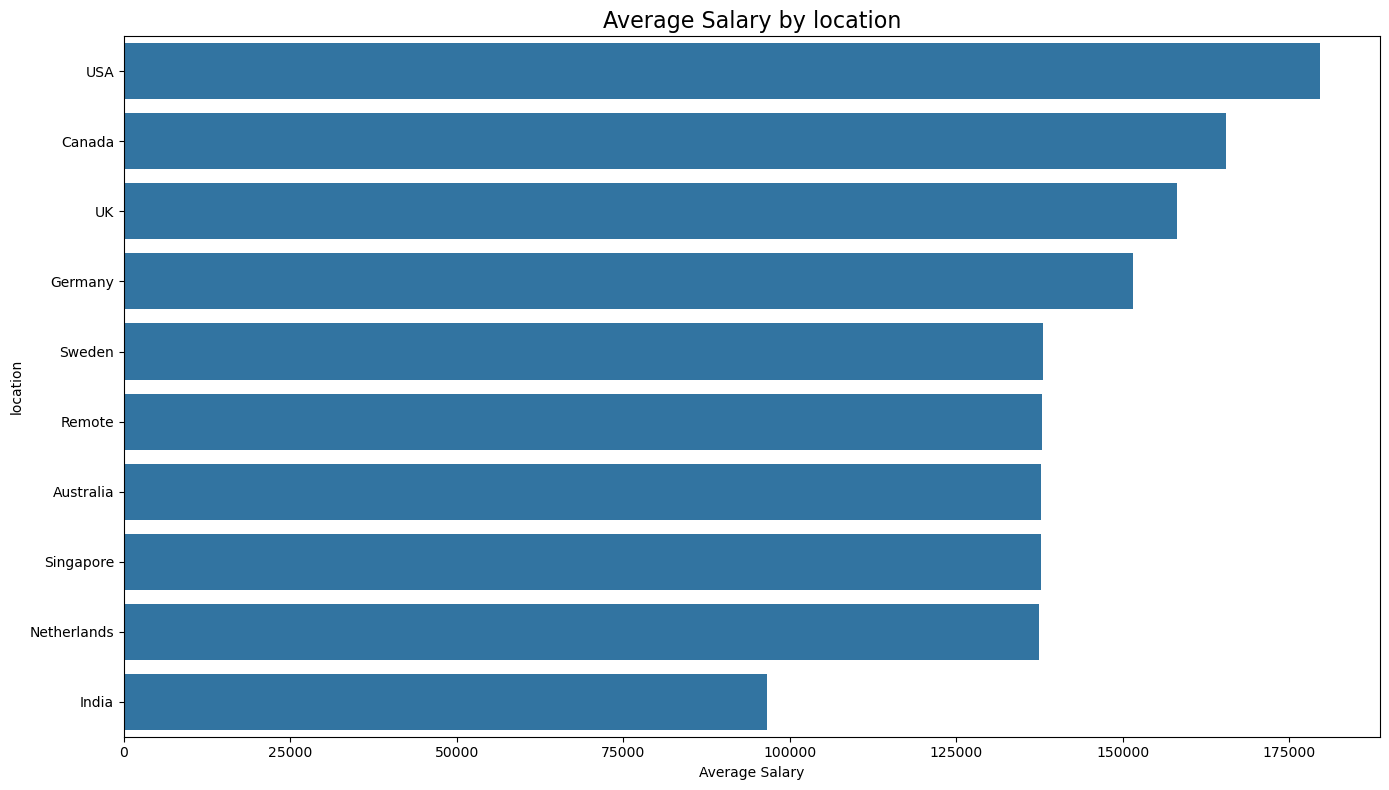

In [36]:
skills_counts = df.groupby('location')['salary'].median().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=skills_counts.values,
    y=skills_counts.index
)

plt.title("Average Salary by location", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("location")

plt.tight_layout()
plt.show()

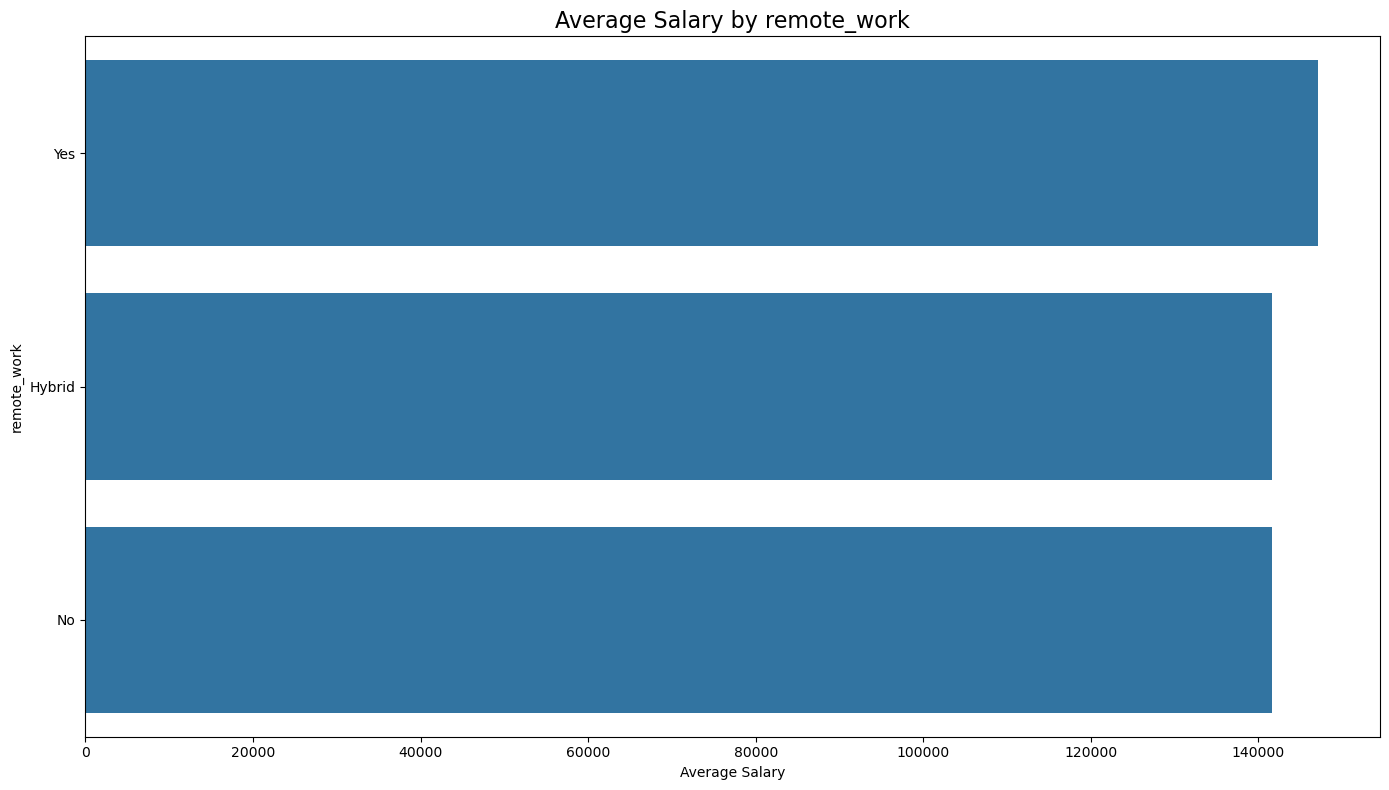

In [37]:
skills_counts = df.groupby('remote_work')['salary'].median().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=skills_counts.values,
    y=skills_counts.index
)

plt.title("Average Salary by remote_work", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("remote_work")

plt.tight_layout()
plt.show()

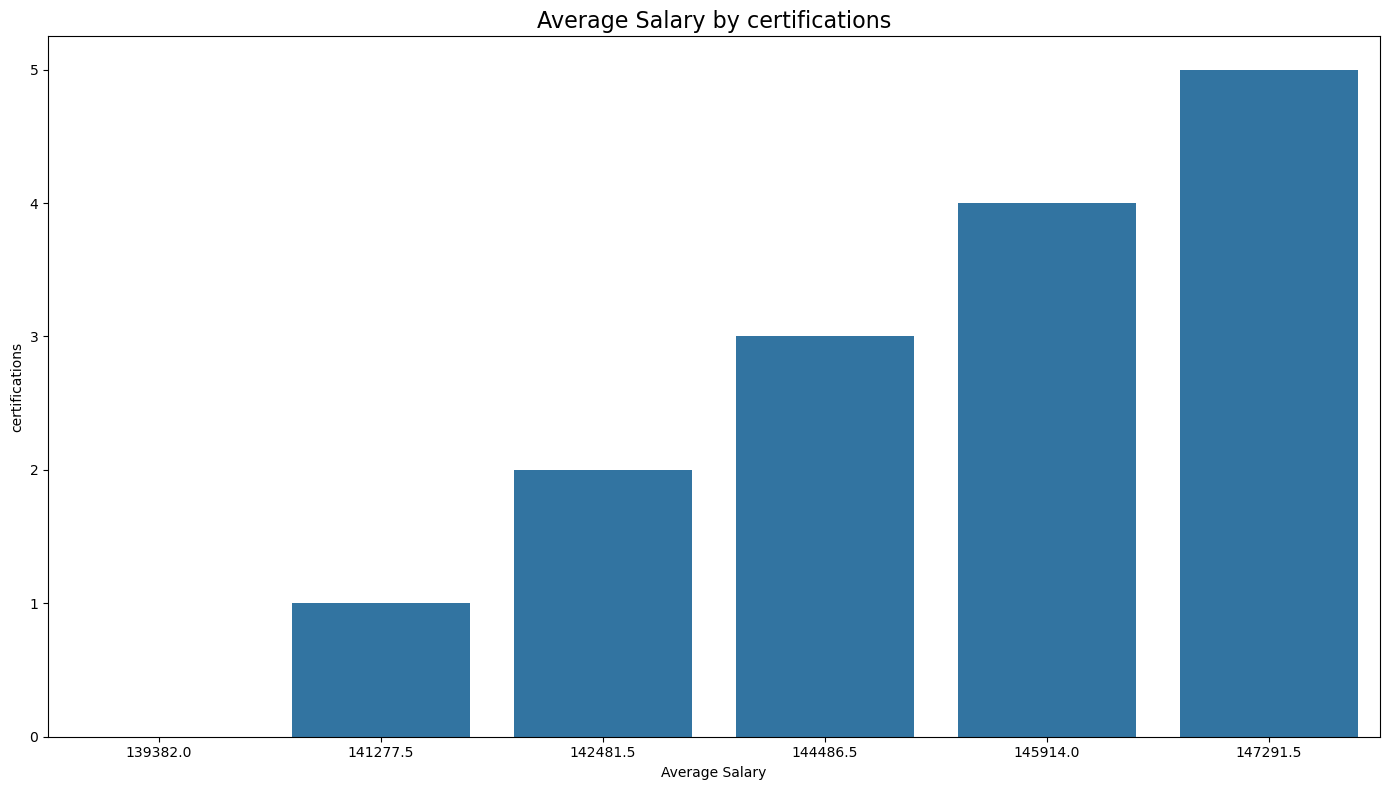

In [38]:
skills_counts = df.groupby('certifications')['salary'].median().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=skills_counts.values,
    y=skills_counts.index
)

plt.title("Average Salary by certifications", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("certifications")

plt.tight_layout()
plt.show()

In [39]:
df.groupby('job_title')['salary'].agg(['mean','median','min','max','count'])

,mean,median,min,max,count
job_title,,,,,
AI Engineer,173498.480640,171674.0,66371,333046,20945
Backend Developer,139202.768663,136678.0,46304,290512,21125
Business Analyst,122551.231354,120562.0,39285,264567,20648
Cloud Engineer,152102.535290,150005.0,45030,292855,20686
Cybersecurity Analyst,148697.695548,146737.0,54224,303178,20959
Data Analyst,119891.696603,118079.5,31867,249354,20722
Data Scientist,147258.214409,145231.5,51349,288049,20890
DevOps Engineer,149959.266791,148021.0,54985,304968,20889
Frontend Developer,132653.842485,130619.0,44964,277053,20633


## For continuous Variable

In [40]:
df[continuous].describe()

,salary
count,250000.000000
mean,145718.080524
std,37407.952729
min,31867.000000
25%,119358.000000
50%,143453.000000
75%,169492.000000
max,333046.000000


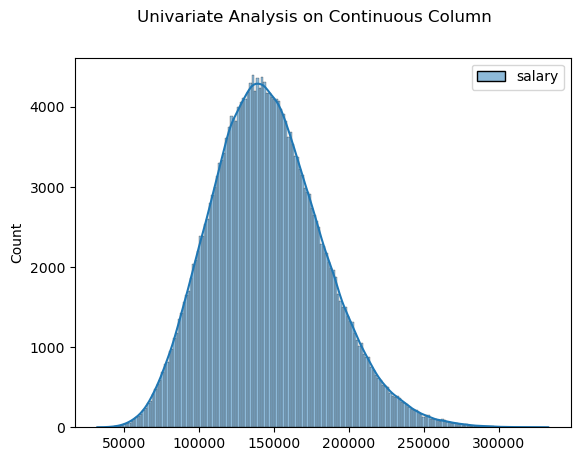

In [41]:
sns.histplot(df[continuous],kde=True)
plt.suptitle("Univariate Analysis on Continuous Column")
plt.show()

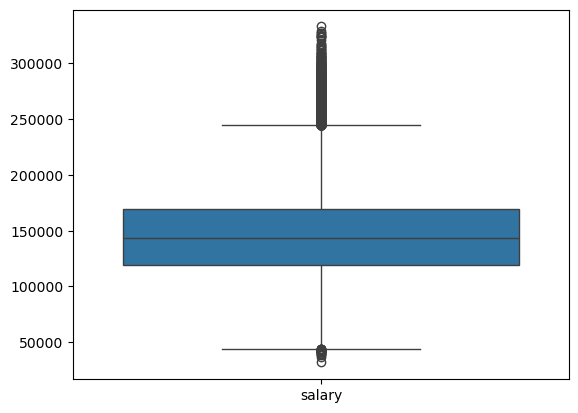

In [42]:
sns.boxplot(df[continuous])
plt.show()

- observations:
1. Salary increases with increased years of experience
2. AI engineers have more salary
3. People with Phds are paid more...<strike> (they are ML/AI enginners probably)</strike>
4. Most phd people are product managers...WHATTT
5. more skill more moneyyy
6. No such big difference of salaries between industries
7. Enterprise people have more salaries
8. Median salary of Enterprise people are much higher than rest type of companies.
9. USA people have more median salary , salary of [Sweden,Australia,Singapore,Netherlands, Remote] are in the same range. India people are the least paid.
10. Remote working people have more salary then hybrid or non remote working people.
11. People with 5 certifications have more median salary
12. Salary has outliers... but the outliers are moneytary... so people can have more salary hence we retained this and worked with respect to median.

## Data Cleaning , Scaling and Transformation  is not required as data is clean and doesnot have skewness.

## Data Encoding

# Ordinal

In [43]:
df["company_size"] = df["company_size"].replace({"Startup":0,"Small":1,"Medium":2,"Large":3,"Enterprise":4})

In [44]:
df["education_level"] = df["education_level"].replace({"High School":0,"Diploma":1,"Bachelor":2,"Master":3,"PhD":4})

In [45]:
inp = df.drop("salary",axis=1)
inp

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications
0,AI Engineer,10,2,2,Healthcare,2,India,Hybrid,2
1,Data Analyst,5,2,17,Telecom,1,Australia,No,0
2,Frontend Developer,18,4,4,Media,2,Singapore,No,1
3,Business Analyst,19,4,13,Retail,2,Canada,Yes,0
4,Product Manager,15,2,7,Manufacturing,3,Sweden,Yes,0
...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,4,2,Telecom,4,India,No,1
249996,Frontend Developer,20,4,7,Telecom,0,Remote,No,2
249997,Business Analyst,1,2,12,Retail,4,India,Yes,0
249998,Data Scientist,0,0,2,Consulting,1,Sweden,Hybrid,5


In [46]:
data = pd.get_dummies(inp,drop_first=True).astype(int)

In [47]:
data.head()

,experience_years,education_level,skills_count,company_size,certifications,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,2,2,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,5,2,17,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,18,4,4,2,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
3,19,4,13,2,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,15,2,7,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


# X & y

In [48]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,2,2,Healthcare,2,India,Hybrid,2,109413
1,Data Analyst,5,2,17,Telecom,1,Australia,No,0,93764
2,Frontend Developer,18,4,4,Media,2,Singapore,No,1,148123
3,Business Analyst,19,4,13,Retail,2,Canada,Yes,0,189123
4,Product Manager,15,2,7,Manufacturing,3,Sweden,Yes,0,165069


In [49]:
X = data
y = df['salary']

In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Modelling : MLR

In [51]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 14)

In [52]:
model_mlr = LinearRegression()
model_mlr.fit(X_train,y_train)
print("Coefficients: ",model_mlr.coef_)
print("Intecept: ", model_mlr.intercept_)

Coefficients:  [ 2.69689386e+03  8.06564771e+03  8.57300233e+02  1.05901561e+04
  1.61305376e+03 -3.43333913e+04 -5.14845575e+04 -2.14400471e+04
 -2.46918833e+04 -5.36981735e+04 -2.69191011e+04 -2.36909845e+04
 -4.08188356e+04 -1.06738475e+04 -1.60952315e+04 -3.22218109e+04
  7.81993286e+00  4.60666712e+01  1.51214418e+02  7.88191545e+01
  2.88730220e+00  8.64467894e+01  7.85154414e+01  3.78323357e+01
  1.06629400e+02  2.79489111e+04  1.40202211e+04 -4.19115245e+04
 -1.77477564e+01  6.22503516e+01  1.95128313e+01 -1.80953115e+00
  2.09892747e+04  4.19765060e+04  2.77584273e+01  5.34704813e+03]
Intecept:  88621.38788260447


In [53]:
# prediction on train data
ypred_train_mlr = model_mlr.predict(X_train)

#evaluation

# prediction on test data
ypred_test_mlr = model_mlr.predict(X_test)

from sklearn.metrics import r2_score
print("Train R2: ",r2_score(y_train,ypred_train_mlr))
print("Test R2: ",r2_score(y_test,ypred_test_mlr))

## Cross VAlidation Score
print("CV Score: ",cross_val_score(model_mlr,X_train,y_train,cv = 5,scoring="r2").mean())

Train R2:  0.9553120919067115
Test R2:  0.9559178208033678
CV Score:  0.9552911003276515


# Modelling : Polynomial Regression

## Power  = 2

In [54]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 14)

In [55]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter = PolynomialFeatures(degree = 2,include_bias = False)

X_train_poly = pd.DataFrame(polynomial_converter.fit_transform(X_train))

In [56]:
model_poly = LinearRegression()
model_poly.fit(X_train_poly,y_train)
print("Coefficients: ",model_poly.coef_)
print("Intecept: ", model_poly.intercept_)

Coefficients:  [ 2.20231016e+03  1.88124785e+03  6.71963057e+02  1.96709111e+03
  1.29092706e+03 -1.38299067e+04 -2.09010280e+04 -8.78225677e+03
 -9.87429514e+03 -2.19998675e+04 -1.09375830e+04 -9.66232464e+03
 -1.67224462e+04 -4.32529864e+03 -6.45906276e+03 -1.28445153e+04
 -3.78676080e+01  3.55189020e+01 -2.08313242e+02 -1.43033741e+02
  7.13324872e+01 -2.07451352e+02 -1.93304244e+01 -1.83908758e+02
 -1.88710246e+02  9.16762420e+03  4.34801191e+03 -1.35056630e+04
 -1.71353638e+02  4.63784863e+01 -2.14596522e+02  4.51601064e+01
  6.79692863e+03  1.34606448e+04 -4.24396253e+01  2.04634129e+03
 -6.11633257e-01 -9.31003862e-01  5.15877947e-01  1.95385247e+02
  1.54818624e+00 -6.96476455e+00 -4.02025723e-01 -9.35135396e+00
 -8.23655507e+00 -2.54616470e+00 -1.41331973e-01  1.49179257e+01
 -7.86573612e-01 -2.05202618e+00 -6.66118397e-01  1.21809160e+00
 -5.15243280e+00 -1.44432223e+01 -2.66152543e+00 -9.42801736e+00
 -6.50375323e+00 -1.22162177e+01 -1.60463326e-01 -2.10059497e+00
 -6.986291

In [57]:
## prediction on train data
ypred_train_poly = model_poly.predict(X_train_poly)

print("Train R2:",r2_score(y_train,ypred_train_poly))

print("CV Score: ",cross_val_score(model_poly,X_train_poly,y_train,cv = 5,scoring="r2").mean())
# data preprocessing on test data
X_test_poly = pd.DataFrame(polynomial_converter.transform(X_test))

#prediction on test data
y_pred_test_poly = model_poly.predict(X_test_poly)

#evaluation on test data
print('Test R2:',r2_score(y_test,y_pred_test_poly))

Train R2: 0.981105866361408
CV Score:  0.9809933320784836
Test R2: 0.9807951264386789


# Modelling : Ridge Regression

In [59]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 14)

In [60]:
from sklearn.model_selection import GridSearchCV
#model
from sklearn.linear_model import Ridge
estimator = Ridge()

#parameters and values
param_grid = {"alpha": np.arange(0.0001, 1.0, 0.01)}
model_hp = GridSearchCV(estimator,param_grid,cv=5,scoring='r2')
model_hp.fit(X_train,y_train)
model_hp.best_params_

{'alpha': 0.10010000000000001}

In [61]:
from sklearn.linear_model import Ridge
ridge_best = Ridge(alpha= 0.10010000000000001)
ridge_best.fit(X_train,y_train)
print("Intercept:",ridge_best.intercept_)
print("Coefficients:",ridge_best.coef_)

ypred_train_ridge = ridge_best.predict(X_train)

from sklearn.metrics import r2_score
print("Train R2:",r2_score(y_train,ypred_train_ridge))

from sklearn.model_selection import cross_val_score
print("CV Score: ",cross_val_score(ridge_best,X_train,y_train,cv=5).mean())

ypred_test_ridge = ridge_best.predict(X_test)
print("Test R2:", r2_score(y_test,ypred_test_ridge))

Intercept: 88619.71189833907
Coefficients: [ 2.69689388e+03  8.06564547e+03  8.57300125e+02  1.05901529e+04
  1.61305436e+03 -3.43311814e+04 -5.14822394e+04 -2.14379132e+04
 -2.46897314e+04 -5.36958436e+04 -2.69169339e+04 -2.36888372e+04
 -4.08165818e+04 -1.06717778e+04 -1.60931312e+04 -3.22196106e+04
  7.82582255e+00  4.60674386e+01  1.51213650e+02  7.88155132e+01
  2.88624115e+00  8.64500185e+01  7.85164674e+01  3.78318004e+01
  1.06633726e+02  2.79484593e+04  1.40198402e+04 -4.19116152e+04
 -1.80614772e+01  6.19376797e+01  1.92062666e+01 -2.12549135e+00
  2.09888574e+04  4.19759885e+04  2.77457464e+01  5.34703150e+03]
Train R2: 0.955312091623836
CV Score:  0.9552911007528622
Test R2: 0.9559178035458532


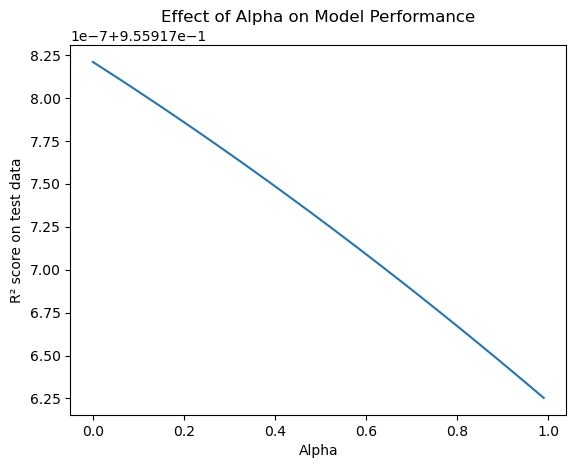

In [62]:
alphas = np.arange(0.0001, 1.0, 0.01)
scores = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

plt.plot(alphas, scores)
plt.xlabel('Alpha')
plt.ylabel('R² score on test data')
plt.title('Effect of Alpha on Model Performance')
plt.show()

# Modelling : Lasso Regression

In [63]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 14)

In [64]:
from sklearn.model_selection import GridSearchCV
#model
from sklearn.linear_model import Lasso
estimator = Lasso()

#parameters and values
param_grid = {"alpha": np.arange(0.0001, 1.0, 0.01)}
model_hp = GridSearchCV(estimator,param_grid,cv=5,scoring='r2')
model_hp.fit(X_train,y_train)
model_hp.best_params_

{'alpha': 0.5201}

In [65]:
lasso_best = Lasso(alpha=0.5201)
lasso_best.fit(X_train,y_train)
print("Intercept:",lasso_best.intercept_)
print("Coefficients:",lasso_best.coef_)

ypred_train_lasso = lasso_best.predict(X_train)

from sklearn.metrics import r2_score
print("Train R2:",r2_score(y_train,ypred_train_lasso))

from sklearn.model_selection import cross_val_score
print("CV Score: ",cross_val_score(lasso_best,X_train,y_train,cv=5).mean())

ypred_test_lasso = lasso_best.predict(X_test)
print("Test R2:", r2_score(y_test,ypred_test_lasso))

Intercept: 88596.63508697091
Coefficients: [ 2.69687955e+03  8.06541353e+03  8.57280255e+02  1.05898688e+04
  1.61289116e+03 -3.42567606e+04 -5.14077179e+04 -2.13633825e+04
 -2.46152595e+04 -5.36215432e+04 -2.68425340e+04 -2.36144155e+04
 -4.07423844e+04 -1.05974421e+04 -1.60190389e+04 -3.21453710e+04
 -1.23539281e+01  1.53763126e+01  1.20417602e+02  4.78767593e+01
 -1.75418415e+01  5.58027766e+01  4.78238123e+01  7.01417618e+00
  7.59990028e+01  2.79288274e+04  1.40001299e+04 -4.19208237e+04
 -2.74457926e+01  4.20765469e+01  0.00000000e+00 -1.16730282e+01
  2.09693173e+04  4.19565667e+04  2.28687653e+01  5.34236650e+03]
Train R2: 0.9553116686062184
CV Score:  0.9552915361523041
Test R2: 0.9559166499472268


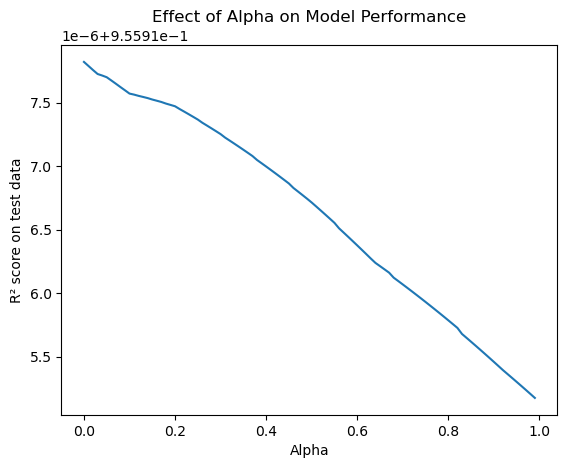

In [66]:
alphas = np.arange(0.0001, 1.0, 0.01)
scores = []

for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

plt.plot(alphas, scores)
plt.xlabel('Alpha')
plt.ylabel('R² score on test data')
plt.title('Effect of Alpha on Model Performance')
plt.show()
